In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pen_absorption.csv", delim_whitespace=True)

# converter nm -> eV
df["E"] = 1240.0 / df["x"]
df = df.sort_values("E", ascending=True)

plt.figure(figsize=(6,4))
plt.plot(df["E"], df["y"], marker="o", linestyle="-")
plt.xlabel("Energia [eV]")
plt.ylabel("y (adimensional)")
plt.title("y vs Energia")
plt.grid(True)
plt.show()

df_renamed = df.rename(columns={"y": "l"})
df_renamed[["E", "l"]].to_json("../configuration/pen_absorption.json", orient="records", indent=2)

TypeError: read_csv() got an unexpected keyword argument 'delim_whitespace'

/tmp/ipykernel_749108/3216486508.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("pen_rayleigth.csv", delim_whitespace=True)


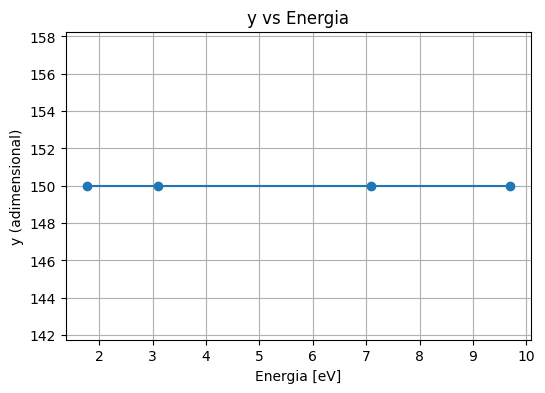

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("pen_rayleigth.csv", delim_whitespace=True)

# converter nm -> eV
df["E"] = 1240.0 / df["x"]
df = df.sort_values("E", ascending=True)

plt.figure(figsize=(6,4))
plt.plot(df["E"], df["y"], marker="o", linestyle="-")
plt.xlabel("Energia [eV]")
plt.ylabel("y (adimensional)")
plt.title("y vs Energia")
plt.grid(True)
plt.show()

df_renamed = df.rename(columns={"y": "l"})
df_renamed[["E", "l"]].to_json("../configuration/pen_raylaigth.json", orient="records", indent=2)

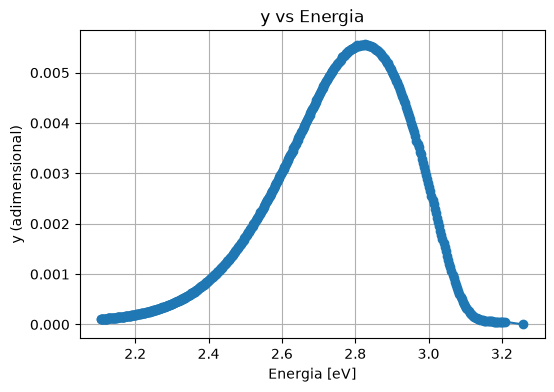

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("emissium_pen.csv", sep=r'\s+') 

# converter nm -> eV
df["E"] = 1240.0 / df["x"]
df = df.sort_values("E", ascending=True)

plt.figure(figsize=(6,4))
plt.plot(df["E"], df["y"], marker="o", linestyle="-")
plt.xlabel("Energia [eV]")
plt.ylabel("y (adimensional)")
plt.title("y vs Energia")
plt.grid(True)
plt.show()

df_renamed = df.rename(columns={"y": "l"})
df_renamed[["E", "l"]].to_json("../configuration/pen_emissium.json", orient="records", indent=2)

In [ ]:
import ROOT
import pandas as pd
import numpy as np


# Correção usando sep=r'\s+' para tratar espaços em branco como delimitadores
df = pd.read_csv("emissium_pen.csv", sep=r'\s+')  
df["E"] = 1240.0 / df["x"]  # Converter nm -> eV
df = df.sort_values("E", ascending=True)

root_file = ROOT.TFile.Open("../build/Data.root", "READ")

tree = root_file.Get("Optical_Properties")

n_bins = 100
e_min, e_max = 2, 3.2

h_sim = ROOT.TH1F("h_sim", "Espectro de Emissao do PEN;Energy [eV];Counts (Normalized)", n_bins, e_min, e_max)
h_theo = ROOT.TH1F("h_theo", "Espectro Teorico;Energy [eV];Counts (Normalized)", n_bins, e_min, e_max)


tree.Draw("1240.0 / emmited_wabelenght_PEN >> h_sim", "", "goff")


for index, row in df.iterrows():
    bin_num = h_theo.FindBin(row["E"])
    h_theo.SetBinContent(bin_num, row["y"])


if h_sim.Integral() > 0:
    h_sim.Scale(1.0 / h_sim.Integral("width"))
if h_theo.Integral() > 0:
    h_theo.Scale(1.0 / h_theo.Integral("width"))


ROOT.gStyle.SetOptStat(0) 

h_sim.SetLineColor(ROOT.kBlue)
h_sim.SetLineWidth(2)
h_sim.SetMarkerStyle(20)
h_sim.SetMarkerColor(ROOT.kBlue)
h_sim.SetMarkerSize(0.8)

h_theo.SetLineColor(ROOT.kRed)
h_theo.SetLineWidth(3)
h_theo.SetLineStyle(2) 

max_y = max(h_sim.GetMaximum(), h_theo.GetMaximum())
h_sim.SetMaximum(max_y * 1.2)


canvas = ROOT.TCanvas("canvas", "PEN Emission", 800, 600)
canvas.SetGrid()

# Desenhar a simulação com marcadores e a teoria com linha suave
h_sim.Draw("E1 P")  
h_theo.Draw("HIST SAME") 

# Adicionar Legenda
legend = ROOT.TLegend(0.65, 0.75, 0.88, 0.88)
legend.AddEntry(h_sim, "Simulation", "lp")
legend.AddEntry(h_theo, "Theoretical (CSV)", "l")
legend.Draw()

# Atualizar e manter a janela aberta
canvas.Update()
canvas.Modified()



Warning in <TCanvas::Constructor>: Deleting canvas with same name: canvas
